In [2]:
#from alibi.explainers import ALE, plot_ale
import joblib
import funciones
import importlib

from sklearn.model_selection import train_test_split

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
importlib.reload(funciones)

<module 'funciones' from 'c:\\Users\\Jorge\\Documents\\Proyectos de programación\\TFG\\Modelos\\Jorge\\funciones.py'>

In [3]:
SPOOF = "..\\..\\Dataset\\Features\\spoof_features.csv"
BONAFIDE = '..\\..\\Dataset\\Features\\bonafide_features.csv'

RANDOM_STATE = 12
TEST_SPLIT = 0.2

In [4]:
df = funciones.carga_datos(ruta_bon=BONAFIDE, ruta_spo=SPOOF, random_state=RANDOM_STATE)

In [5]:
X = df.drop(columns=['label', 'filename'])
y = df['label']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SPLIT, random_state=RANDOM_STATE, stratify=y)

In [7]:
# Cargar el modelo
modelo_rf = joblib.load('modelo_Random_Forest.pkl')
modelo_lgbm = joblib.load('modelo_LightGBM.pkl')
modelo_svm = joblib.load('modelo_SVM.pkl')

# SHAP - RF

In [ ]:
funciones.explica_shap(modelo=modelo_rf, X_train=X_train, X_test=X_test, n_show=1, local=True)

In [ ]:
funciones.explica_shap(modelo=modelo_rf, X_train=X_train, X_test=X_test, n_show=0, local=False)

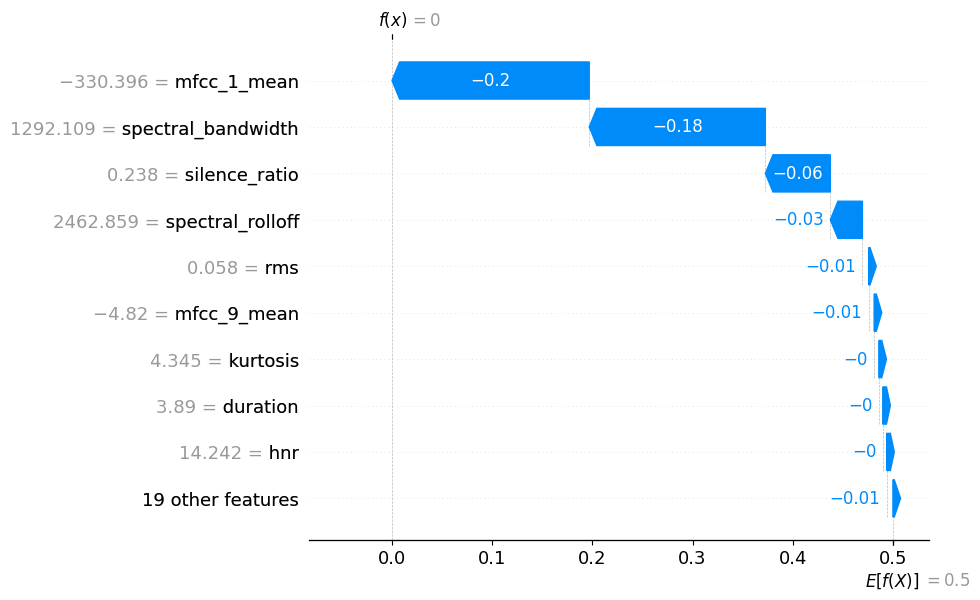

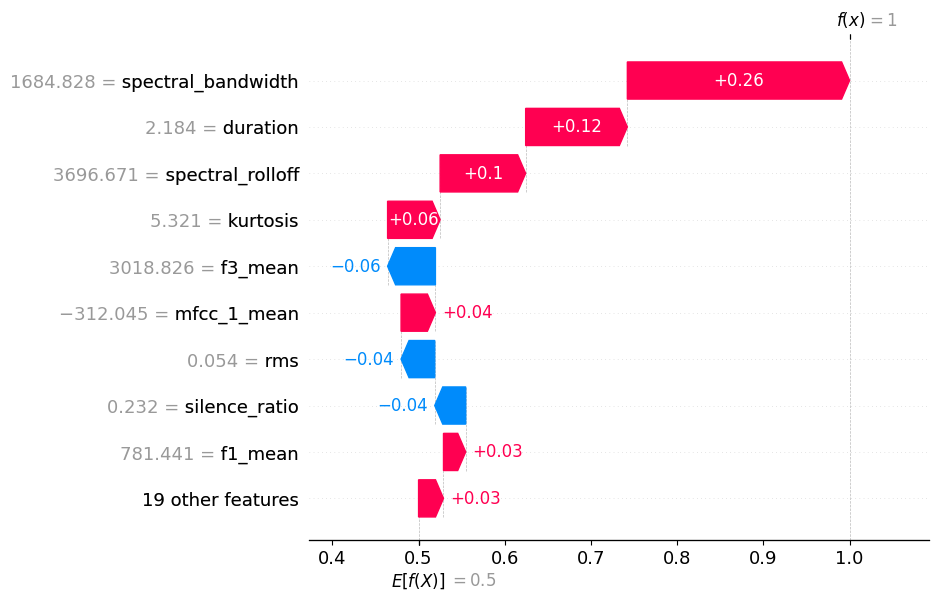

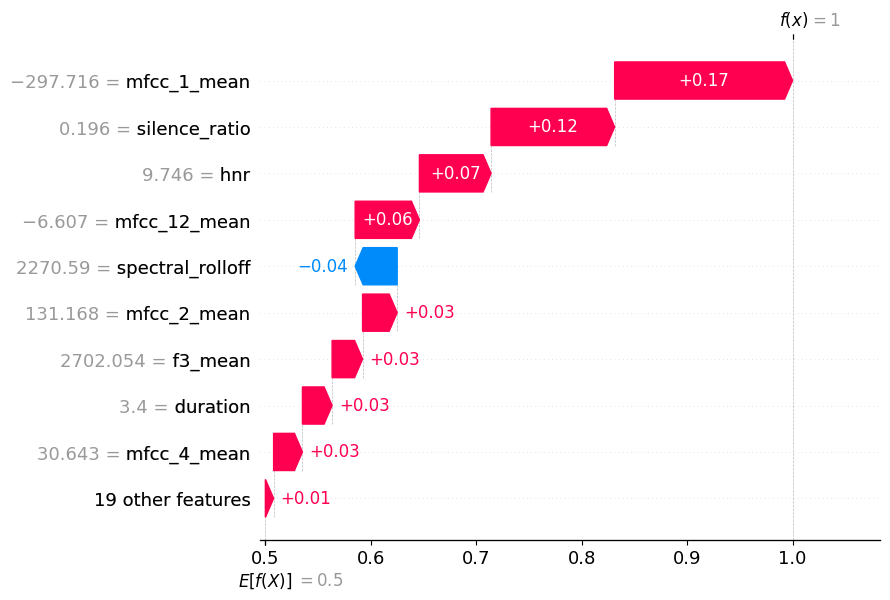

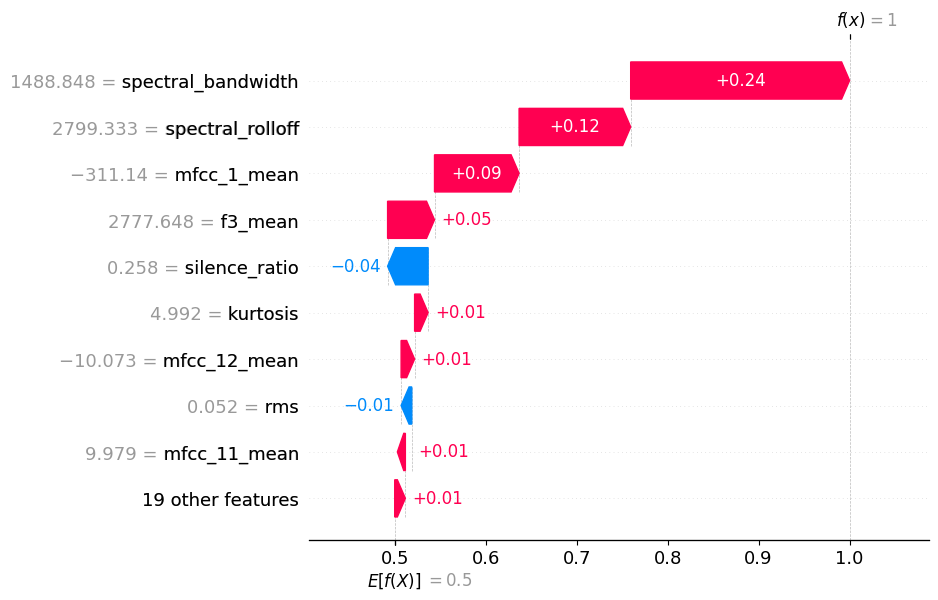

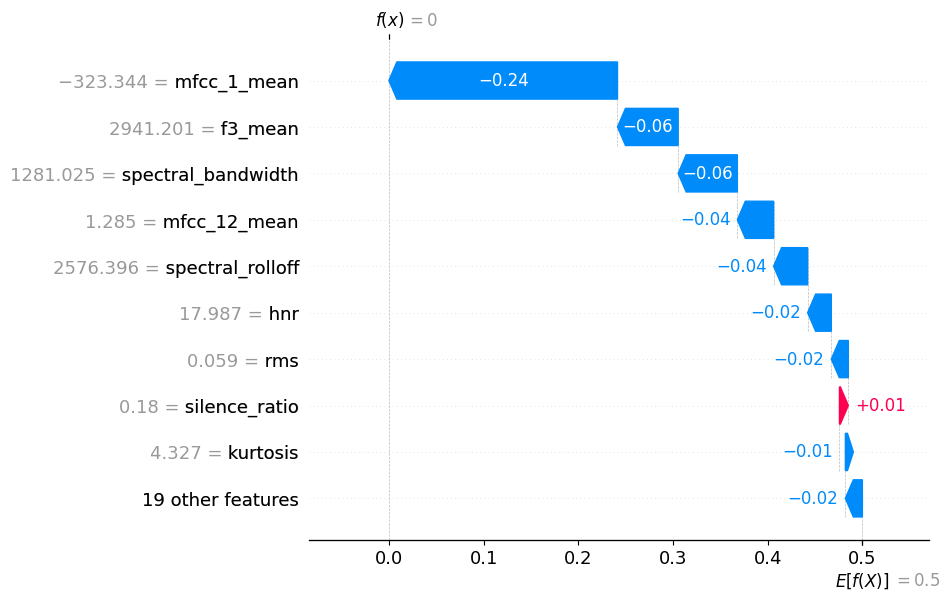


 EVALUACIÓN: Random Forest

MÉTRICAS PRINCIPALES:
   • Accuracy:  0.9500  (Porcentaje total de aciertos)
   • Precision: 1.0000  (De los que dije que eran reales, ¿cuántos lo eran?)
   • Recall:    0.9000  (De los reales, ¿cuántos detecté?)
   • F1-Score:  0.9474  (Balance precision-recall)
   • AUC-ROC:   0.9900  (Capacidad discriminativa)
   • MCC:       0.9045  (Coeficiente de correlación de Matthews)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real (1)     0.9091    1.0000    0.9524        10
      IA (0)     1.0000    0.9000    0.9474        10

    accuracy                         0.9500        20
   macro avg     0.9545    0.9500    0.9499        20
weighted avg     0.9545    0.9500    0.9499        20


ANÁLISIS DE ERRORES:
   • Verdaderos Negativos (Reales bien clasificados): 10
   • Verdaderos Positivos (IA bien clasificados): 9
   • Falsos Positivos (Reales clasificados como IA): 0
   • Falsos Negativos (IA clasificados como Reales): 1

In [25]:
funciones.drop_features_explica(
    modelo=modelo_rf,
    model_name='Random Forest', 
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    feats='spectral_flatness', 
    n_show=5, 
    evalua_modelo=True,
    explicacion='shap'
)

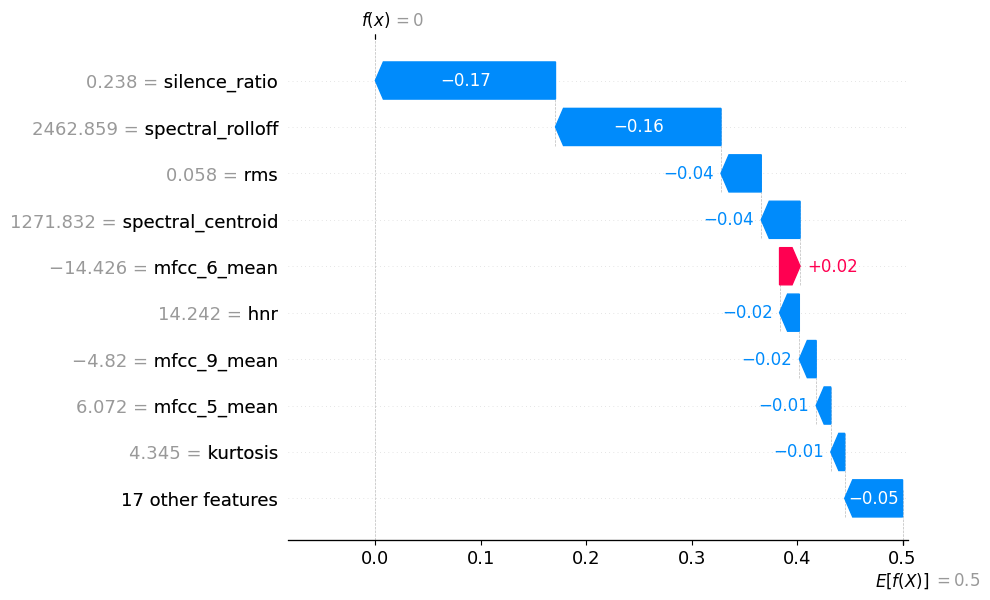

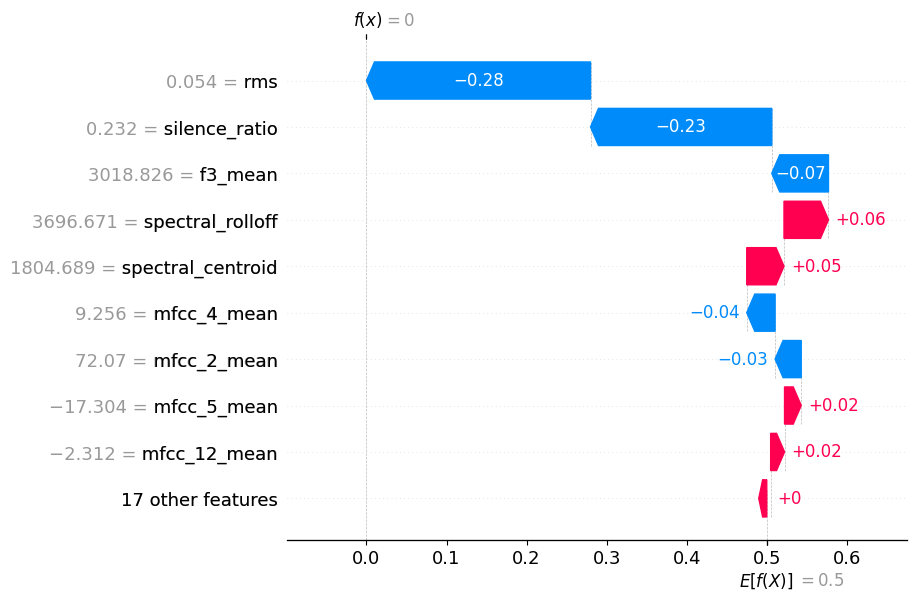

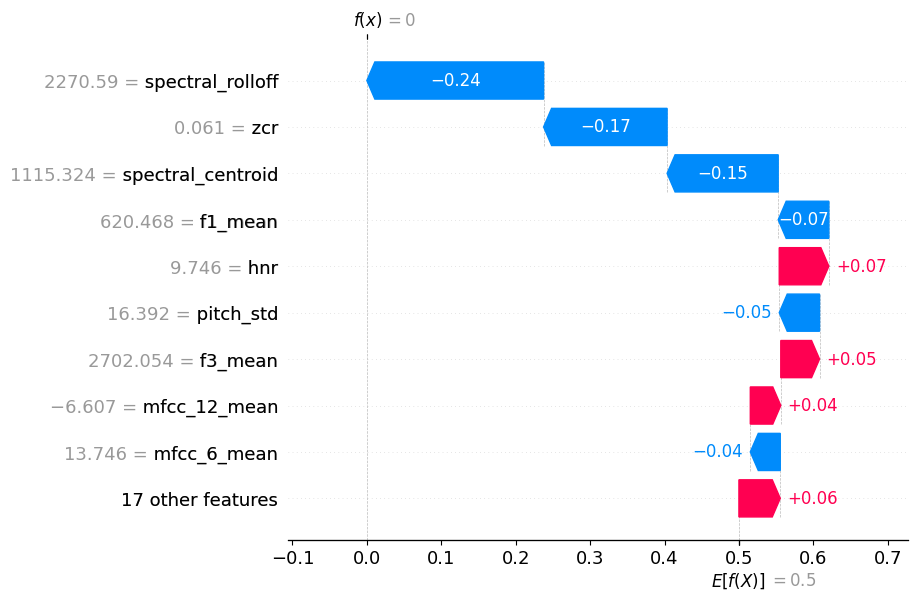

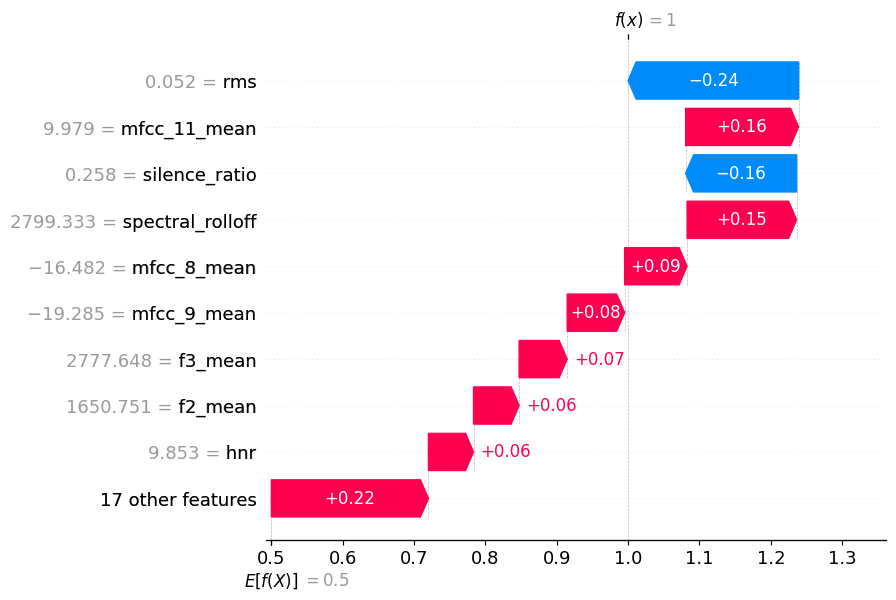

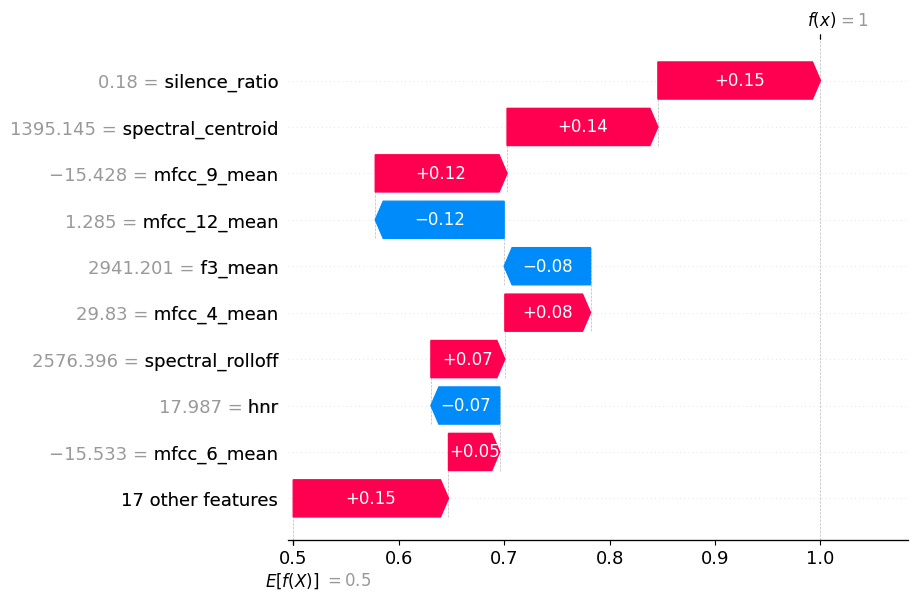


 EVALUACIÓN: Random Forest

MÉTRICAS PRINCIPALES:
   • Accuracy:  0.6500  (Porcentaje total de aciertos)
   • Precision: 0.7143  (De los que dije IA, ¿cuántos eran?)
   • Recall:    0.5000    (De los IA, ¿cuántos detecté?)
   • F1-Score:  0.5882  (Balance precision-recall)
   • AUC-ROC:   0.8600  (Capacidad discriminativa)
   • MCC:       0.3145  (Coeficiente de correlación de Matthews)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real (0)     0.6154    0.8000    0.6957        10
      IA (1)     0.7143    0.5000    0.5882        10

    accuracy                         0.6500        20
   macro avg     0.6648    0.6500    0.6419        20
weighted avg     0.6648    0.6500    0.6419        20


ANÁLISIS DE ERRORES:
   • Verdaderos Negativos (Reales bien clasificados): 8
   • Verdaderos Positivos (IA bien clasificados): 5
   • Falsos Positivos (Reales clasificados como IA): 2
   • Falsos Negativos (IA clasificados como Reales): 5
   • Error tipo I 

In [ ]:
funciones.drop_features_explica(
    modelo=modelo_rf,
    model_name='Random Forest',
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    feats=['spectral_flatness', 'mfcc_1_mean', 'spectral_bandwidth'], 
    n_show=5, 
    evalua_modelo=True,
    explicacion='shap'
)

# SHAP - LGBM

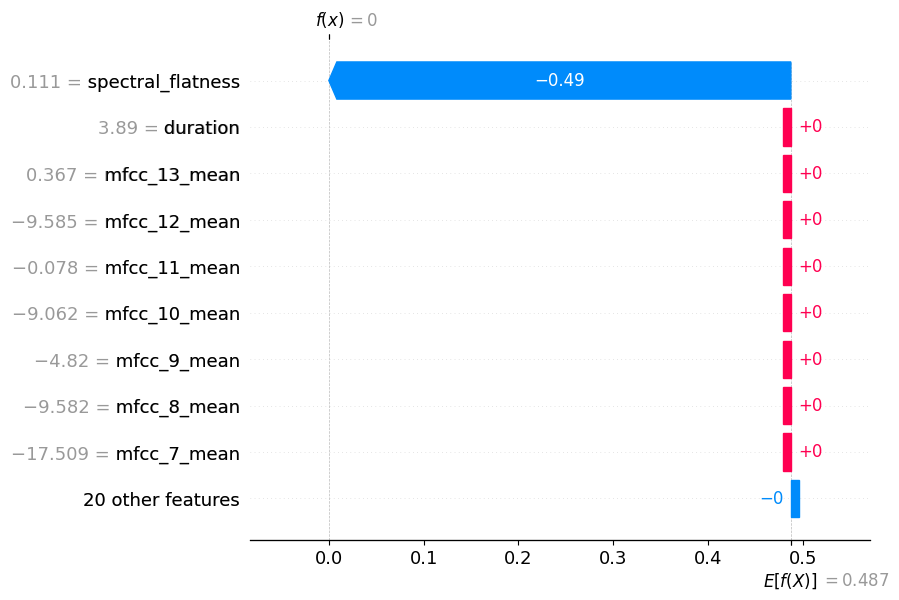

In [9]:
funciones.explica_shap(modelo=modelo_lgbm, X_train=X_train, X_test=X_test, n_show=1, local=True)

c:\Users\Jorge\Documents\Proyectos de programación\TFG\Modelos\Jorge\funciones.py:210: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


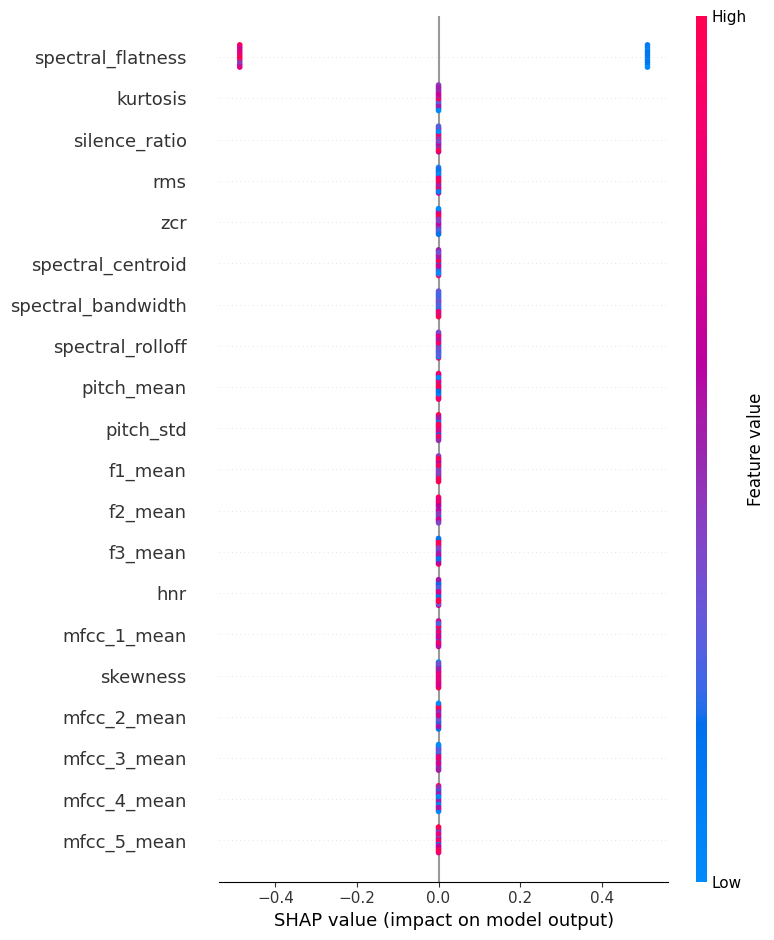

In [11]:
funciones.explica_shap(modelo=modelo_lgbm, X_train=X_train, X_test=X_test, n_show=0, local=False)

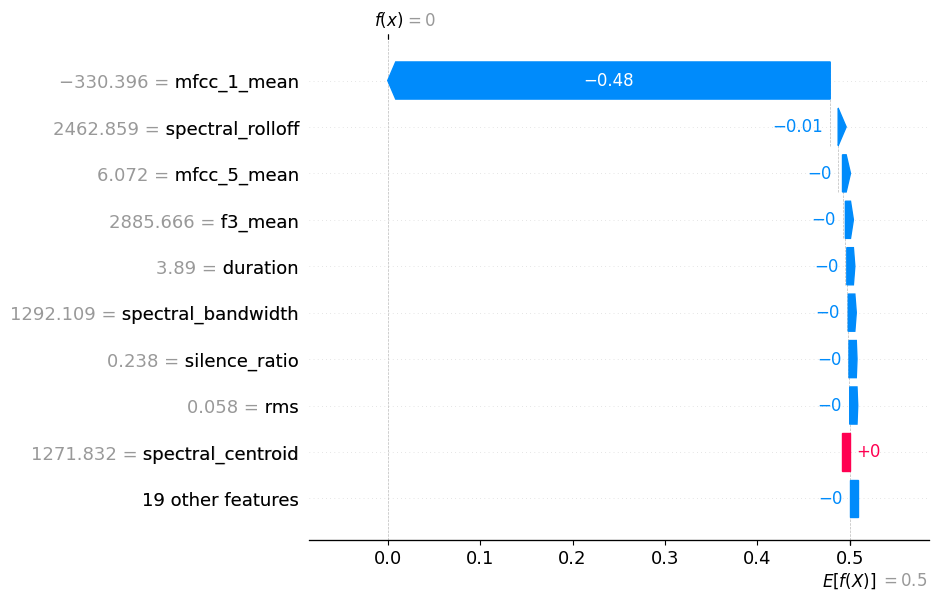

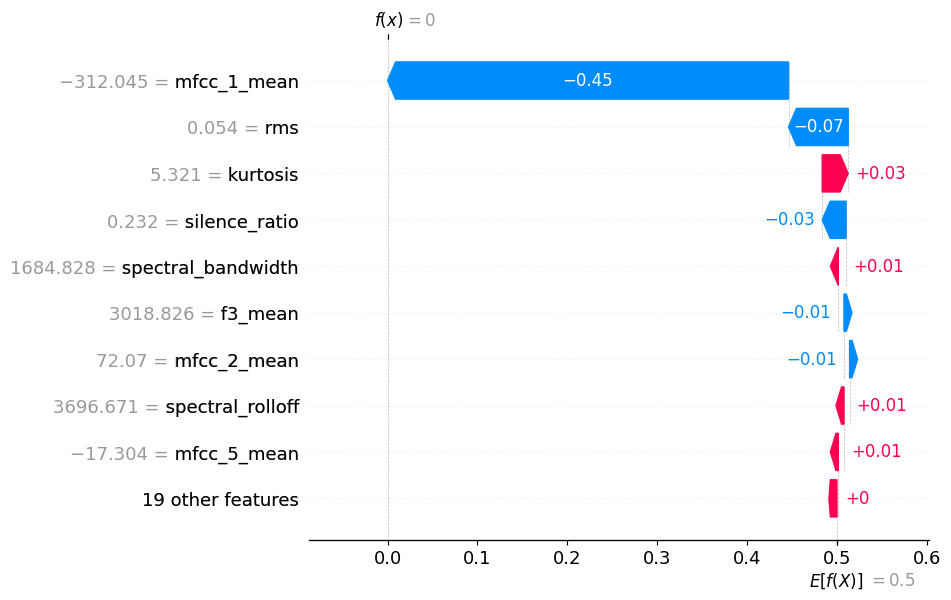

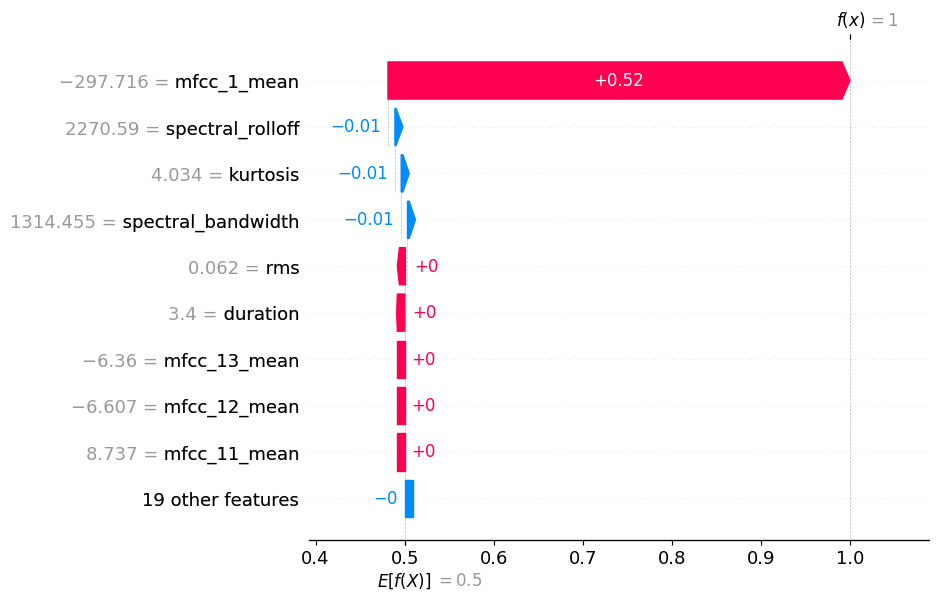


 EVALUACIÓN: LightGBM

MÉTRICAS PRINCIPALES:
   • Accuracy:  0.8000  (Porcentaje total de aciertos)
   • Precision: 0.8750  (De los que dije que eran reales, ¿cuántos lo eran?)
   • Recall:    0.7000  (De los reales, ¿cuántos detecté?)
   • F1-Score:  0.7778  (Balance precision-recall)
   • AUC-ROC:   0.9600  (Capacidad discriminativa)
   • MCC:       0.6124  (Coeficiente de correlación de Matthews)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real (1)     0.7500    0.9000    0.8182        10
      IA (0)     0.8750    0.7000    0.7778        10

    accuracy                         0.8000        20
   macro avg     0.8125    0.8000    0.7980        20
weighted avg     0.8125    0.8000    0.7980        20


ANÁLISIS DE ERRORES:
   • Verdaderos Negativos (Reales bien clasificados): 9
   • Verdaderos Positivos (IA bien clasificados): 7
   • Falsos Positivos (Reales clasificados como IA): 1
   • Falsos Negativos (IA clasificados como Reales): 3
   • 

In [ ]:
funciones.drop_features_explica(
    modelo=modelo_lgbm,
    model_name='LightGBM', 
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    feats='spectral_flatness', 
    n_show=3, 
    evalua_modelo=True,
    explicacion='shap'
)

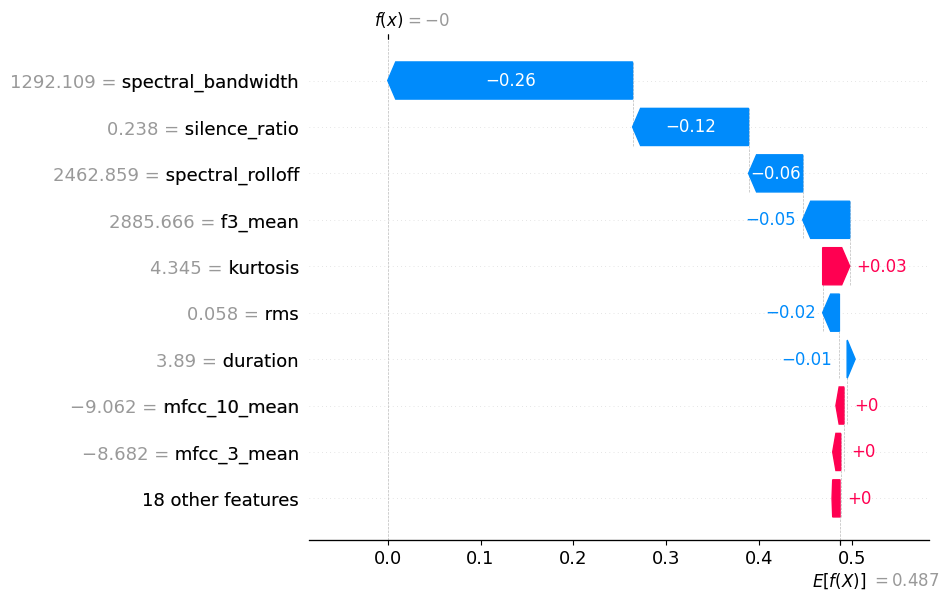

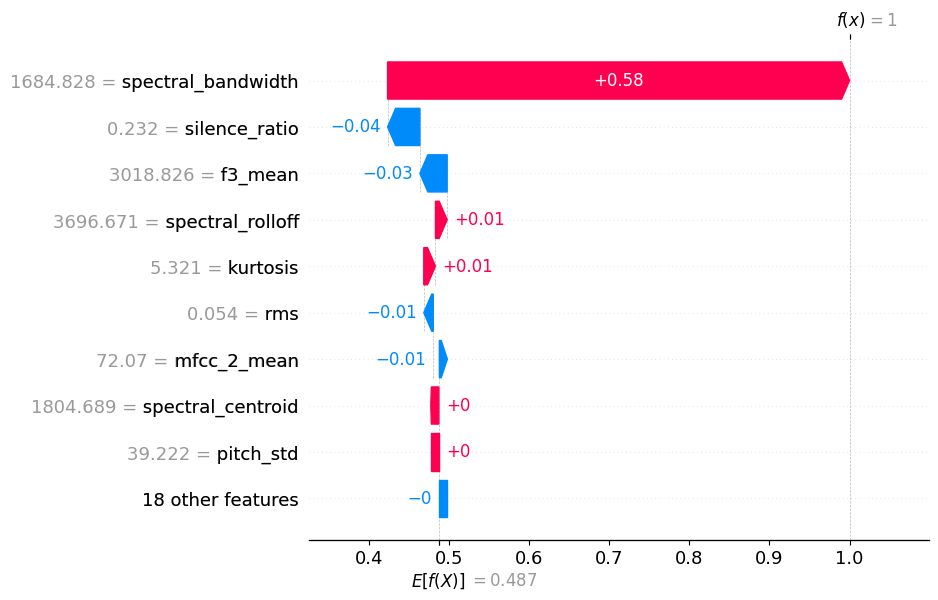

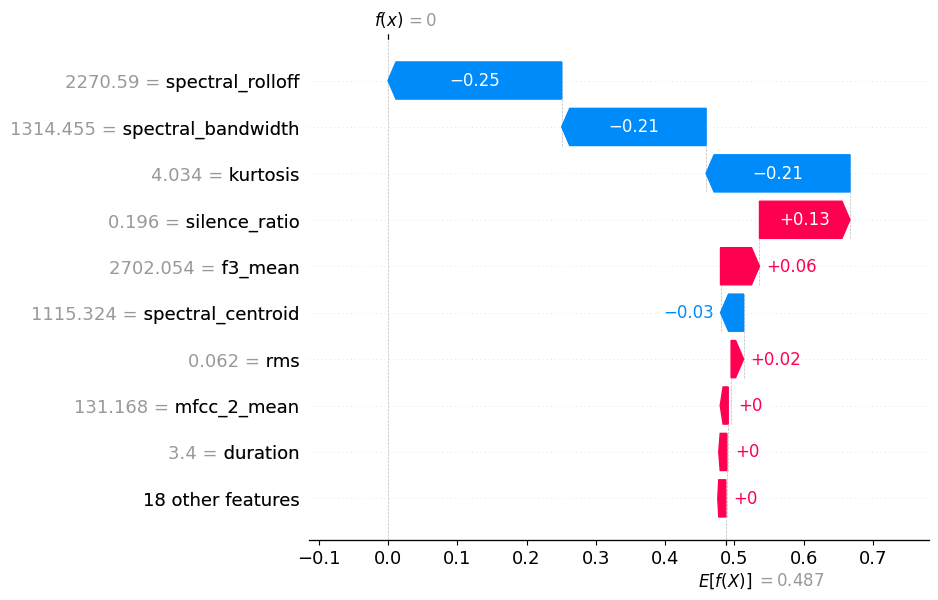


 EVALUACIÓN: LightGBM

MÉTRICAS PRINCIPALES:
   • Accuracy:  0.8500  (Porcentaje total de aciertos)
   • Precision: 0.8889  (De los que dije que eran reales, ¿cuántos lo eran?)
   • Recall:    0.8000  (De los reales, ¿cuántos detecté?)
   • F1-Score:  0.8421  (Balance precision-recall)
   • AUC-ROC:   0.9400  (Capacidad discriminativa)
   • MCC:       0.7035  (Coeficiente de correlación de Matthews)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real (1)     0.8182    0.9000    0.8571        10
      IA (0)     0.8889    0.8000    0.8421        10

    accuracy                         0.8500        20
   macro avg     0.8535    0.8500    0.8496        20
weighted avg     0.8535    0.8500    0.8496        20


ANÁLISIS DE ERRORES:
   • Verdaderos Negativos (Reales bien clasificados): 9
   • Verdaderos Positivos (IA bien clasificados): 8
   • Falsos Positivos (Reales clasificados como IA): 1
   • Falsos Negativos (IA clasificados como Reales): 2
   • 

In [ ]:
funciones.drop_features_explica(
    modelo=modelo_lgbm,
    model_name='LightGBM',
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    feats=['spectral_flatness', 'mfcc_1_mean'], 
    n_show=3, 
    evalua_modelo=True,
    explicacion='shap'
)

# SHAP - SVM

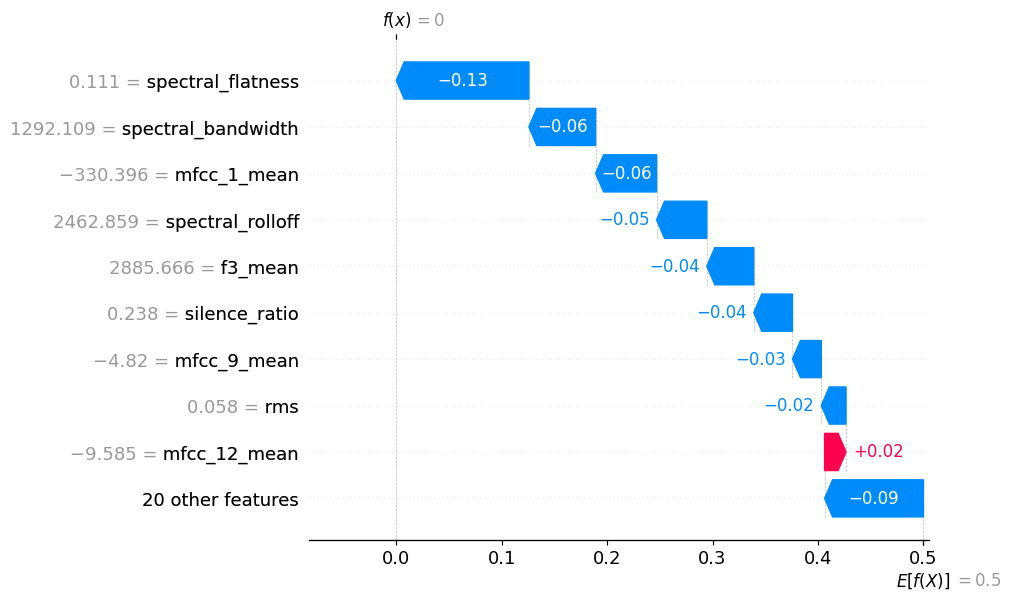

In [16]:
funciones.explica_shap(modelo=modelo_svm, X_train=X_train, X_test=X_test, n_show=1, local=True)

c:\Users\Jorge\Documents\Proyectos de programación\TFG\Modelos\Jorge\funciones.py:214: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  y_pred = modelo.predict(X_test)


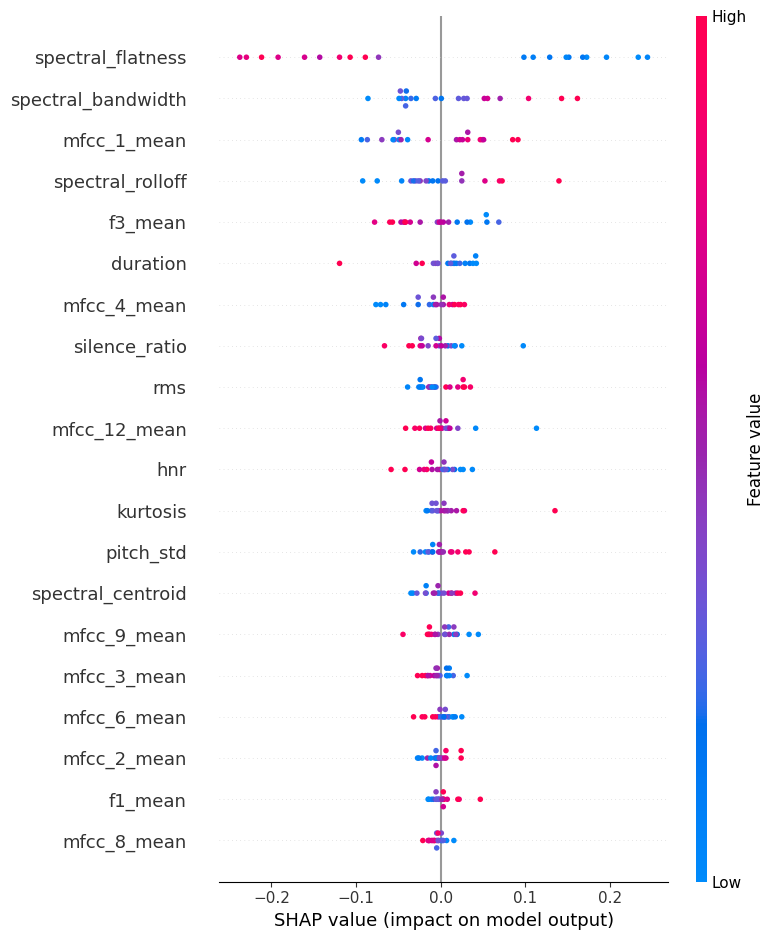

In [17]:
funciones.explica_shap(modelo=modelo_svm, X_train=X_train, X_test=X_test, n_show=1, local=False)

In [11]:
modelo_svm.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('svm',
   SVC(C=1, class_weight='balanced', gamma=0.01, probability=True, random_state=12))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'svm': SVC(C=1, class_weight='balanced', gamma=0.01, probability=True, random_state=12),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'svm__C': 1,
 'svm__break_ties': False,
 'svm__cache_size': 200,
 'svm__class_weight': 'balanced',
 'svm__coef0': 0.0,
 'svm__decision_function_shape': 'ovr',
 'svm__degree': 3,
 'svm__gamma': 0.01,
 'svm__kernel': 'rbf',
 'svm__max_iter': -1,
 'svm__probability': True,
 'svm__random_state': 12,
 'svm__shrinking': True,
 'svm__tol': 0.001,
 'svm__verbose': False}

In [10]:
funciones.drop_features_explica(
    modelo=modelo_svm,
    model_name='SVM', 
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    feats='spectral_flatness', 
    n_show=3, 
    evalua_modelo=True,
    explicacion='shap'
)

TypeError: SVC.__init__() got an unexpected keyword argument 'memory'

In [ ]:
funciones.drop_features_explica(
    modelo=modelo_svm,
    model_name='SVM',
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    feats=['spectral_flatness', 'mfcc_1_mean', 'spectral_bandwidth'], 
    n_show=3, 
    evalua_modelo=True,
    explicacion='shap'
)

TypeError: SVC.__init__() got an unexpected keyword argument 'memory'

# LIME

In [8]:
html = funciones.explica_lime(modelo=modelo_rf, columnas=X.columns, X_train=X_train, X_test=X_test)

display(html)

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [9]:
html = funciones.explica_lime(modelo=modelo_lgbm, columnas=X.columns, X_train=X_train, X_test=X_test)

display(html)

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [10]:
html = funciones.explica_lime(modelo=modelo_svm, columnas=X.columns, X_train=X_train, X_test=X_test)

display(html)

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# DiCE

In [12]:
# Eliminar características no relevantes
X_train_clean = X_train.drop(columns=['filename'], errors='ignore')
X_test_clean = X_test.drop(columns=['filename'], errors='ignore')

In [13]:
funciones.explica_dice(modelo=modelo_rf, X_train=X_train_clean, y_train=y_train, X_test=X_test)

100%|██████████| 1/1 [00:00<00:00,  4.43it/s]

Query instance (original outcome : 0)


,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness,pitch_mean,pitch_std,f1_mean,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,skewness,kurtosis,label
0,3.890063,0.058137,0.099838,1271.831787,1292.109375,2462.858643,0.110641,199.331436,26.57995,624.03479,...,-17.509218,-9.581953,-4.819844,-9.0617,-0.078036,-9.584771,0.367151,0.11118,4.344761,0



Diverse Counterfactual set (new outcome: 1)


,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness,pitch_mean,pitch_std,f1_mean,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,skewness,kurtosis,label
0,-,-,-,-,-,-,0.0085693521,-,-,-,...,-,-19.0127779,-,-,-,-,-,-,-,-
1,-,-,-,1769.708,-,-,0.0140804753,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
2,-,0.063278444,-,-,-,-,0.0182716957,-,-,-,...,-,-,-,-,-,-,-,-,-,-


In [ ]:
funciones.explica_dice(modelo=modelo_lgbm, X_train=X_train_clean, y_train=y_train, X_test=X_test)

100%|██████████| 1/1 [00:00<00:00,  3.08it/s]

Query instance (original outcome : 0)


,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness,pitch_mean,pitch_std,f1_mean,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,skewness,kurtosis,label
0,3.890063,0.058137,0.099838,1271.831787,1292.109375,2462.858643,0.110641,199.331436,26.57995,624.03479,...,-17.509218,-9.581953,-4.819844,-9.0617,-0.078036,-9.584771,0.367151,0.11118,4.344761,0



Diverse Counterfactual set (new outcome: 1)


,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness,pitch_mean,pitch_std,f1_mean,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,skewness,kurtosis,label
0,-,-,-,-,-,-,0.0170038721,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,-,0.0270864069,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,0.0294502619,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0


In [22]:
funciones.explica_dice(modelo=modelo_svm, X_train=X_train_clean, y_train=y_train, X_test=X_test, escalar=True)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.47it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


UserConfigValidationException: No counterfactuals found for any of the query points! Kindly check your configuration.